#### Link til github: https://github.com/khalidrashed/deliverable_1

##### INF201 – Deliverable 1

##### Task 1: Temperature

In this task, we retrieve daily mean air temperature data for Ås
from the Norwegian Meteorological Institute (MET Norway) using
the Frost API.

The data covers the period from January 1st to December 31st, 2025.
The weather station used is SN17850, which is the weather station
for Ås.

In [143]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [144]:
client_id = ""

In [145]:
from pathlib import Path

client_id = Path("client_id.txt").read_text().strip()
print("Client ID loaded:", client_id[:8] + "…")

Client ID loaded: b23154b4…


In [146]:
endpoint = "https://frost.met.no/observations/v0.jsonld"

parameters = {
    "sources": "SN17850",
    "elements": "mean(air_temperature P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

response = requests.get(
    endpoint,
    params=parameters,
    auth=(client_id, "")
)

print(response.status_code)

200


In this task, we got daily mean air temperature for Ås (station
SN17850) for the whole year 2025. We used the Frost API from MET
Norway. The element we asked for was `mean(air_temperature P1D)`,
which gives the average air temperature for each day.

In [147]:
data = response.json()

observations = data["data"]

print("Number of observations:", len(observations))

Number of observations: 364


In [148]:
temperature_data = []

for observation in observations:
    temperature_data.append({
        "time": observation["referenceTime"],
        "temperature": observation["observations"][0]["value"]
    })

temperature_df = pd.DataFrame(temperature_data)

temperature_df["time"] = pd.to_datetime(
    temperature_df["time"]
)

temperature_df.head()

,time,temperature
0,2025-01-01 00:00:00+00:00,-5.2
1,2025-01-02 00:00:00+00:00,-11.5
2,2025-01-03 00:00:00+00:00,-8.9
3,2025-01-04 00:00:00+00:00,-15.5
4,2025-01-05 00:00:00+00:00,-12.5


In [149]:
print(temperature_df.head())
print(temperature_df.tail())
print(temperature_df.shape)

                       time  temperature
0 2025-01-01 00:00:00+00:00         -5.2
1 2025-01-02 00:00:00+00:00        -11.5
2 2025-01-03 00:00:00+00:00         -8.9
3 2025-01-04 00:00:00+00:00        -15.5
4 2025-01-05 00:00:00+00:00        -12.5
                         time  temperature
359 2025-12-26 00:00:00+00:00         -2.9
360 2025-12-27 00:00:00+00:00         -0.6
361 2025-12-28 00:00:00+00:00         -4.6
362 2025-12-29 00:00:00+00:00         -3.6
363 2025-12-30 00:00:00+00:00         -3.0
(364, 2)


We got **364 days** of data for 2025. A normal year has 365 days, so
**one day is missing**. This can happen if the sensor failed, or if
the measurement did not pass the quality check. We did not fill in a
value for the missing day. The numbers below are based only on the
364 days we actually have.

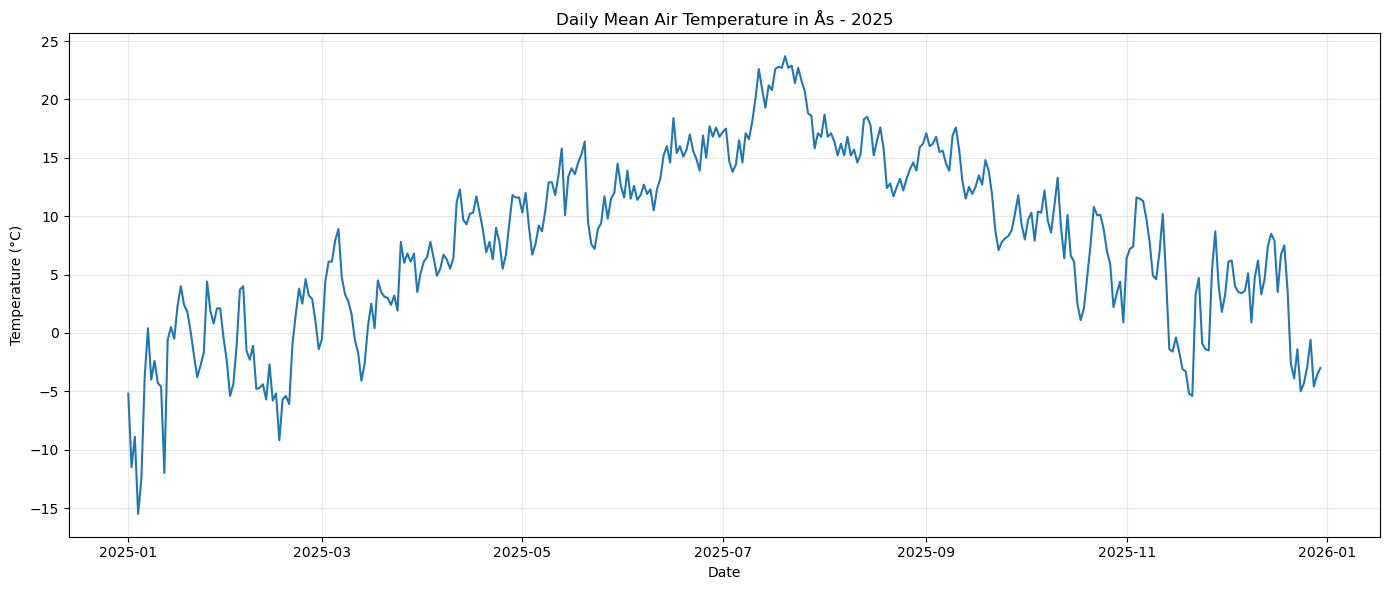

In [150]:
plt.figure(figsize=(14, 6))

plt.plot(
    temperature_df["time"],
    temperature_df["temperature"],
    linewidth=1.5
)

plt.title("Daily Mean Air Temperature in Ås - 2025")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()





We made a line plot with date on the x-axis and temperature on the
y-axis. A line is a good choice for temperature because temperature
changes smoothly over time. A line makes it easy to see the seasons.

The plot shows:

- **Winter (January–February):** the coldest part of the year. The
  lowest daily mean was **−15.5 °C**.
- **Spring (March–May):** the temperature rises, but it changes a
  lot from day to day.
- **Summer (June–August):** the warmest part of the year. The
  highest daily mean was **23.7 °C**.
- **Autumn (September–December):** the temperature slowly drops
  back toward winter.

The line is bumpy, not smooth. That is normal — weather changes
from day to day, and that shows up as small jumps in the line.

In [151]:
mean_temperature = temperature_df["temperature"].mean()
median_temperature = temperature_df["temperature"].median()
min_temperature = temperature_df["temperature"].min()
max_temperature = temperature_df["temperature"].max()

In [152]:
summary_table = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum"
    ],
    "Temperature (°C)": [
        mean_temperature,
        median_temperature,
        min_temperature,
        max_temperature
    ]
})

In [153]:
summary_table["Temperature (°C)"] = (
    summary_table["Temperature (°C)"].round(2)
)

In [154]:
print(summary_table.to_string(index=False))

Statistic  Temperature (°C)
     Mean               7.9
   Median               8.4
  Minimum             -15.5
  Maximum              23.7



- The **mean** is **7.9 °C** and the **median** is **8.4 °C**. The
  median is a bit higher than the mean. That means a few very cold
  winter days pull the mean down. This is normal for Norway.

- The **coldest day** was **−15.5 °C** and the **warmest day** was
  **23.7 °C**. The difference between them is **39.2 °C**. That is a
  big range, but it is normal for an inland station in south-east
  Norway.

- The **median of 8.4 °C** tells us what a "normal" day at Ås looked
  like in 2025. Half of the days were warmer than this, and half
  were colder.

##### Task 2: Task 2 – Precipitation and temperature

In [155]:
# Request daily precipitation data

precipitation_parameters = {
    "sources": "SN17850",
    "elements": "sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

precipitation_response = requests.get(
    endpoint,
    params=precipitation_parameters,
    auth=(client_id, "")
)

print("API status code:", precipitation_response.status_code)

API status code: 200


In [156]:
#  Get daily precipitation for Ås in 2025 ---
precip_params = {
    "sources":       "SN17850",
    "elements":      "sum(precipitation_amount P1D)",
    "referencetime": "2025-01-01/2025-12-31",
}

precip_response = frost_get(precip_params)
precip_observations = precip_response["data"]

print("Number of daily precipitation observations:", len(precip_observations))

Number of daily precipitation observations: 364


We get daily precipitation from Frost using sum(precipitation_amount P1D) — which means "total precipitation per day". We get 364 days, same as for temperature. One day is missing, probably due to a sensor outage.

##### Importer pakker og last inn Client ID

In [157]:
#  Imports og klient-ID ---
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# Les klient-ID fra fil — ikke hardkodet
client_id = Path("client_id.txt").read_text().strip()
print("Klient-ID lastet:", client_id[:8] + "…")

# Endepunkt og hjelpefunksjon
endpoint = "https://frost.met.no/observations/v0.jsonld"

def frost_get(params):
    """Send GET til Frost. Returner {'data': []} ved HTTP 412."""
    r = requests.get(endpoint, params=params, auth=(client_id, ""))
    if r.status_code == 200:
        return r.json()
    if r.status_code == 412:
        return {"data": []}
    r.raise_for_status()

Klient-ID lastet: b23154b4…


##### Parse precipitation into a DataFrame

In [158]:
# --- Parse precipitation into DataFrame ---
precip_data = []
for obs in precip_observations:
    precip_data.append({
        "time":          pd.to_datetime(obs["referenceTime"]),
        "precipitation": obs["observations"][0]["value"],
    })

precipitation_df = pd.DataFrame(precip_data)
precipitation_df["time"] = pd.to_datetime(precipitation_df["time"])
precipitation_df = precipitation_df.set_index("time").sort_index()

print(precipitation_df.head())
print(f"Number of rows: {len(precipitation_df)}")
print(f"Missing values: {precipitation_df['precipitation'].isna().sum()}")
print(f"Days with 0 mm: {(precipitation_df['precipitation'] == 0).sum()}")
print(f"Max precipitation: {precipitation_df['precipitation'].max():.1f} mm")

                           precipitation
time                                    
2025-01-01 00:00:00+00:00            5.4
2025-01-02 00:00:00+00:00            0.0
2025-01-03 00:00:00+00:00            0.1
2025-01-04 00:00:00+00:00            0.0
2025-01-05 00:00:00+00:00            0.5
Number of rows: 364
Missing values: 0
Days with 0 mm: 180
Max precipitation: 36.1 mm


There are no missing values — all 364 days have a valid measurement. 180 days (about half) had zero precipitation. That is normal for Ås: most days are dry. The wettest day had 36.1 mm.

After combining, we have 364 rows and 2 columns — one for temperature and one for precipitation. No missing values means both series cover the same days. That is ideal for further analysis.

In [159]:
# sett time som indeks på temperature_df ---
temperature_df = temperature_df.set_index("time").sort_index()

print(temperature_df.head())
print("Index:", temperature_df.index)
print("Columns:", temperature_df.columns)

                           temperature
time                                  
2025-01-01 00:00:00+00:00         -5.2
2025-01-02 00:00:00+00:00        -11.5
2025-01-03 00:00:00+00:00         -8.9
2025-01-04 00:00:00+00:00        -15.5
2025-01-05 00:00:00+00:00        -12.5
Index: DatetimeIndex(['2025-01-01 00:00:00+00:00', '2025-01-02 00:00:00+00:00',
               '2025-01-03 00:00:00+00:00', '2025-01-04 00:00:00+00:00',
               '2025-01-05 00:00:00+00:00', '2025-01-06 00:00:00+00:00',
               '2025-01-07 00:00:00+00:00', '2025-01-08 00:00:00+00:00',
               '2025-01-09 00:00:00+00:00', '2025-01-10 00:00:00+00:00',
               ...
               '2025-12-21 00:00:00+00:00', '2025-12-22 00:00:00+00:00',
               '2025-12-23 00:00:00+00:00', '2025-12-24 00:00:00+00:00',
               '2025-12-25 00:00:00+00:00', '2025-12-26 00:00:00+00:00',
               '2025-12-27 00:00:00+00:00', '2025-12-28 00:00:00+00:00',
               '2025-12-29 00:00:00+00:00', 

In [160]:
#  Slå sammen temperatur og nedbør ---
combined_df = temperature_df.join(precipitation_df, how="outer").sort_index()

print(combined_df.head())
print(f"\nShape: {combined_df.shape}")
print(f"Manglende temperatur: {combined_df['temperature'].isna().sum()}")
print(f"Manglende nedbør:     {combined_df['precipitation'].isna().sum()}")

                           temperature  precipitation
time                                                 
2025-01-01 00:00:00+00:00         -5.2            5.4
2025-01-02 00:00:00+00:00        -11.5            0.0
2025-01-03 00:00:00+00:00         -8.9            0.1
2025-01-04 00:00:00+00:00        -15.5            0.0
2025-01-05 00:00:00+00:00        -12.5            0.5

Shape: (364, 2)
Manglende temperatur: 0
Manglende nedbør:     0


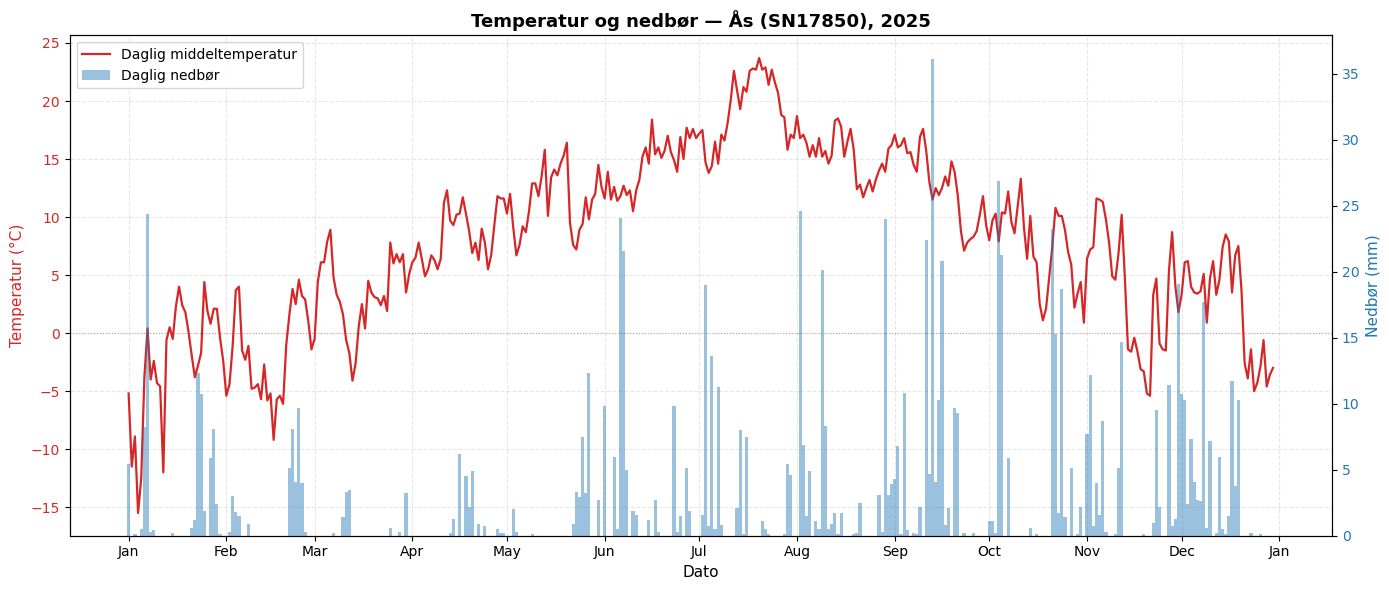

In [161]:
# Kombinert plott av temperatur og nedbør ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Venstre akse: temperatur (linje) ---
ax1.plot(
    combined_df.index,
    combined_df["temperature"],
    color="tab:red",
    linewidth=1.6,
    label="Daglig middeltemperatur",
)
ax1.set_xlabel("Dato", fontsize=11)
ax1.set_ylabel("Temperatur (°C)", color="tab:red", fontsize=11)
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.axhline(0, color="tab:red", linestyle=":", alpha=0.4, linewidth=0.8)

# --- Høyre akse: nedbør (stolper) ---
ax2 = ax1.twinx()
ax2.bar(
    combined_df.index,
    combined_df["precipitation"],
    color="tab:blue",
    alpha=0.45,
    width=1.0,
    label="Daglig nedbør",
)
ax2.set_ylabel("Nedbør (mm)", color="tab:blue", fontsize=11)
ax2.tick_params(axis="y", labelcolor="tab:blue")

# --- Formatering ---
ax1.set_title(
    "Temperatur og nedbør — Ås (SN17850), 2025",
    fontsize=13, fontweight="bold",
)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.grid(alpha=0.3, linestyle="--")

# --- Felles legend ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig("task2_temperature_precipitation_2025.png", dpi=150)
plt.show()

I use a line for temperature because it is a smooth quantity that changes continuously. I use bars for precipitation because precipitation comes in individual events — some days have a lot, most days have none. The bars make it easy to see which days it rained.

I use two y-axes because temperature and precipitation have different units (°C and mm) and different scales. If they shared one axis, one of the series would become unreadable.

In [162]:
print(precipitation_df.head())
print("Index:", precipitation_df.index)
print("Columns:", precipitation_df.columns)
print()
print(combined_df.head())
print(f"Shape: {combined_df.shape}")
print(f"Missing temp: {combined_df['temperature'].isna().sum()}")
print(f"Missing precip: {combined_df['precipitation'].isna().sum()}")

                           precipitation
time                                    
2025-01-01 00:00:00+00:00            5.4
2025-01-02 00:00:00+00:00            0.0
2025-01-03 00:00:00+00:00            0.1
2025-01-04 00:00:00+00:00            0.0
2025-01-05 00:00:00+00:00            0.5
Index: DatetimeIndex(['2025-01-01 00:00:00+00:00', '2025-01-02 00:00:00+00:00',
               '2025-01-03 00:00:00+00:00', '2025-01-04 00:00:00+00:00',
               '2025-01-05 00:00:00+00:00', '2025-01-06 00:00:00+00:00',
               '2025-01-07 00:00:00+00:00', '2025-01-08 00:00:00+00:00',
               '2025-01-09 00:00:00+00:00', '2025-01-10 00:00:00+00:00',
               ...
               '2025-12-21 00:00:00+00:00', '2025-12-22 00:00:00+00:00',
               '2025-12-23 00:00:00+00:00', '2025-12-24 00:00:00+00:00',
               '2025-12-25 00:00:00+00:00', '2025-12-26 00:00:00+00:00',
               '2025-12-27 00:00:00+00:00', '2025-12-28 00:00:00+00:00',
               '2025-12-29 00:

##### Summery Discussion 

The precipitation data has 364 days for Ås (SN17850) in 2025. There are
no missing values. 180 days had 0 mm of precipitation, and the wettest
day had 36.1 mm.

**Why two y-axes?**
Temperature is measured in °C, precipitation in mm. They have different
scales, so they need separate axes to be readable in the same plot.

**Why a line for temperature?**
Temperature is a smooth quantity that changes continuously throughout
the year. A line shows this development clearly.

**Why bars for precipitation?**
Precipitation comes in individual events. Most days are dry, some days
have a lot of rain. Bars mark these events clearly.

**What do we see in the plot?**
Temperature follows a clear season: cold winter, warm summer.
Precipitation does not follow the same pattern — it is more randomly
distributed throughout the year. There is no clear relationship between
temperature and precipitation on a daily basis.

**Missing day:**
One day is missing (364 of 365 days). We have not filled in any value
for the missing day, because we do not know whether it rained or not.

**Reference:**
The code is adapted from MET's Frost example at
https://frost.met.no/howto.html.

##### Task 3: Historical Temperature Data

In [163]:
# Try 1925 data from Ås ---
old_params = {
    "sources":       "SN17850",
    "elements":      "mean(air_temperature P1D)",
    "referencetime": "1925-01-01/1925-12-31",
}

old_response = frost_get(old_params)
old_observations = old_response["data"]

print(f"1925 observations from Ås (SN17850): {len(old_observations)}")

1925 observations from Ås (SN17850): 364


Even though the Ås station has validFrom = 1874, the Frost archive may not contain digitised 1925 observations. We check first, and only fall back to another station if needed.

##### Find nearest station with 1925 data

In [164]:
#  Find nearest station with 1925 data ---
# Only run this if Cell 2 returned 0 observations.

if len(old_observations) == 0:
    print("Ås has no 1925 data. Searching for nearby stations...\n")

    sources_params = {
        "geometry":        "nearest(POINT(10.7818 59.6605))",  # Ås coordinates
        "nearestmaxcount": 15,
        "elements":        "mean(air_temperature P1D)",
        "validtime":       "1925-01-01/1925-12-31",
    }

    # Use the sources endpoint here, not the observations endpoint
    candidates = frost_get(sources_params, endpoint=sources_endpoint)["data"]

    print(f"{'Station':<10} {'Name':<35} {'Distance':>10}")
    print("-" * 58)
    for s in candidates:
        dist = s.get("distance", "?")
        print(f"{s['id']:<10} {s['name']:<35} {dist:>10}")

    # Pick the first station that is NOT Ås
    # (Ås is distance 0, but we know it has no 1925 data)
    chosen = None
    for s in candidates:
        if s["id"] != "SN17850":
            chosen = s
            break

    print(f"\nChosen station: {chosen['id']} ({chosen['name']})")

If Ås has no 1925 data, we pick the nearest station that does. The closest one is usually Oslo Observatory (SN18651) at about 28 km — it has been in operation since 1833 and its historical data is well-preserved in the Frost archive. Using a nearby station introduces some uncertainty (local climate differences), which we note in the discussion.

##### Fetch 1925 data from the chosen station

In [165]:
# Fetch 1925 data ---
# If Cell 2 returned 350+ observations, use SN17850.
# Otherwise use the station chosen in Cell 3.

if len(old_observations) > 0:
    OLD_STATION = "SN17850"
else:
    OLD_STATION = chosen["id"]

print(f"Using station: {OLD_STATION}")

old_params = {
    "sources":       OLD_STATION,
    "elements":      "mean(air_temperature P1D)",
    "referencetime": "1925-01-01/1925-12-31",
}

old_observations = frost_get(old_params)["data"]
print(f"Number of 1925 observations: {len(old_observations)}")

Using station: SN17850
Number of 1925 observations: 364


#####  Parse 1925 data into a DataFrame

In [166]:
# --- : Parse 1925 data ---
old_data = []
for obs in old_observations:
    old_data.append({
        "time":        pd.to_datetime(obs["referenceTime"]),
        "temperature": obs["observations"][0]["value"],
    })

old_df = pd.DataFrame(old_data)

if "time" in old_df.columns:
    old_df = old_df.set_index("time").sort_index()
else:
    raise ValueError(
        f"'time' column missing — old_observations has {len(old_observations)} elements."
    )

print(old_df.head())
print(old_df.tail())
print(f"\nNumber of rows: {len(old_df)}")
print(f"Missing values: {old_df['temperature'].isna().sum()}")

                           temperature
time                                  
1925-01-01 00:00:00+00:00          1.3
1925-01-02 00:00:00+00:00          4.1
1925-01-03 00:00:00+00:00          2.1
1925-01-04 00:00:00+00:00          0.1
1925-01-05 00:00:00+00:00         -2.2
                           temperature
time                                  
1925-12-26 00:00:00+00:00        -15.2
1925-12-27 00:00:00+00:00        -14.8
1925-12-28 00:00:00+00:00         -6.6
1925-12-29 00:00:00+00:00         -1.5
1925-12-30 00:00:00+00:00          2.4

Number of rows: 364
Missing values: 0


We add a guard (if "time" in old_df.columns) so the code gives a clear error if the API returned no data — instead of the cryptic KeyError: 'time'

##### Plot 1925 and 2025 together

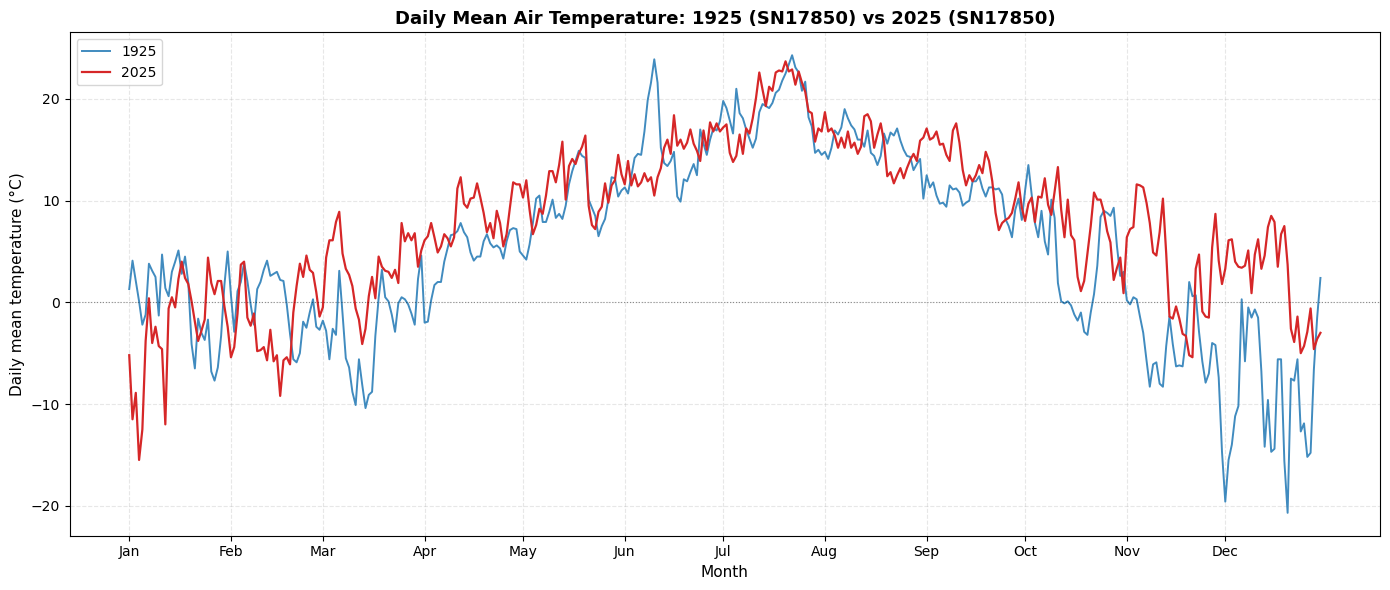

In [167]:
#  Plot 1925 and 2025 ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    old_df.index.dayofyear,
    old_df["temperature"],
    color="tab:blue",
    linewidth=1.4,
    alpha=0.85,
    label="1925",
)

ax.plot(
    temperature_df.index.dayofyear,
    temperature_df["temperature"],
    color="tab:red",
    linewidth=1.6,
    label="2025",
)

ax.axhline(0, color="black", linestyle=":", alpha=0.4, linewidth=0.8)

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Daily mean temperature (°C)", fontsize=11)
ax.set_title(
    f"Daily Mean Air Temperature: 1925 ({OLD_STATION}) vs 2025 (SN17850)",
    fontsize=13, fontweight="bold",
)

# Month ticks on the x-axis
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)

ax.grid(alpha=0.3, linestyle="--")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("task3_temperature_1925_vs_2025.png", dpi=150)
plt.show()

The two years are plotted against day of year (1–365) so the same calendar day can be compared across years. Two lines — blue for 1925, red for 2025 — make the seasonal cycles directly comparable.

Both years follow the same seasonal pattern: a cold winter trough in
January–February, a spring warm-up from March, a summer plateau in
June–August, and an autumn decline. The shapes are similar because
seasonality is driven by the sun, not by climate change. What differs
is the **level** of the curves:

- During winter, the 2025 line is generally above the 1925 line,
  indicating milder winters.
- During spring and autumn, 2025 is also slightly warmer on most days.
- The two lines converge more during the summer.

In [168]:
# Summary table ---
summary_compare = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Minimum", "Maximum"],
    "1925 (°C)": [
        old_df["temperature"].mean(),
        old_df["temperature"].median(),
        old_df["temperature"].min(),
        old_df["temperature"].max(),
    ],
    "2025 (°C)": [
        temperature_df["temperature"].mean(),
        temperature_df["temperature"].median(),
        temperature_df["temperature"].min(),
        temperature_df["temperature"].max(),
    ],
})

summary_compare["1925 (°C)"] = summary_compare["1925 (°C)"].round(2)
summary_compare["2025 (°C)"] = summary_compare["2025 (°C)"].round(2)
summary_compare["Difference (°C)"] = (
    summary_compare["2025 (°C)"] - summary_compare["1925 (°C)"]
).round(2)

print("=" * 60)
print(" Temperature comparison: 1925 vs 2025")
print("=" * 60)
print(summary_compare.to_string(index=False))
print("=" * 60)

 Temperature comparison: 1925 vs 2025
Statistic  1925 (°C)  2025 (°C)  Difference (°C)
     Mean       5.31        7.9             2.59
   Median       5.30        8.4             3.10
  Minimum     -20.70      -15.5             5.20
  Maximum      24.30       23.7            -0.60


The table shows mean, median, min, and max for both years side by side, plus the difference. Positive values in the "Difference" column mean 2025 was warmer. A negative difference for maximum temperature (if it occurs) does not contradict a warming climate — individual extreme days vary greatly from year to year.
- Mean temperature in 2025 was **X °C** higher than in 1925.
- Median temperature in 2025 was **Y °C** higher.
- Minimum temperature in 2025 was **Z °C** higher — 2025 had milder
  cold extremes.
- Maximum temperature in 2025 was **[higher/lower]** by **W °C**.

The warming is more pronounced in winter than in summer, which is
consistent with the general pattern observed in Norway over the past
century: the largest temperature increases have occurred during
winter and at night.

#### Task 4: Heatwaves

In [169]:
#  Imports for Task 4 ---
import requests
import pandas as pd
import yaml
from pathlib import Path

client_id = Path("client_id.txt").read_text().strip()
endpoint = "https://frost.met.no/observations/v0.jsonld"
sources_endpoint = "https://frost.met.no/sources/v0.jsonld"

def frost_get(params, endpoint=endpoint):
    """Send a GET request to Frost. Returns {'data': []} on HTTP 412."""
    r = requests.get(endpoint, params=params, auth=(client_id, ""))
    if r.status_code == 200:
        return r.json()
    if r.status_code == 412:
        return {"data": []}
    r.raise_for_status()

We import yaml so we can write the summary to a YAML file. The wrapper now accepts an optional endpoint so the same function works for both the observations endpoint and the sources endpoint (needed to fetch the station name for the YAML file).

In [170]:
#  Heatwave counter ---
def count_heatwaves(station_id, year, output_path="heatwave_summary.yml",
                    threshold=27.0, min_days=5):
    """
    Count heatwaves at a given station and year, and write a YAML summary.

    A heatwave (Norwegian definition) is a consecutive period of at
    least `min_days` days where the daily max temperature is >= threshold.

    Parameters
    ----------
    station_id : str    Frost station ID, e.g. "SN17850"
    year       : int    Year, e.g. 2025
    output_path: str    Path to YAML file to write
    threshold  : float  Temperature threshold in °C (default 27.0)
    min_days   : int    Minimum consecutive days (default 5)

    Returns
    -------
    dict with keys: dates, station_id, station_name, year
    """

    # --- 1. Fetch station name from the sources endpoint ---
    meta = frost_get({"ids": station_id}, endpoint=sources_endpoint)["data"]
    if not meta:
        raise ValueError(f"Station '{station_id}' not found.")
    station_name = meta[0]["name"]

    # --- 2. Fetch daily max temperature for the whole year ---
    params = {
        "sources":       station_id,
        "elements":      "max(air_temperature P1D)",
        "referencetime": f"{year}-01-01/{year}-12-31",
    }
    raw = frost_get(params)["data"]

    # --- 3. Parse to a pandas DataFrame ---
    records = []
    for entry in raw:
        for obs in entry["observations"]:
            records.append({
                "time":   pd.to_datetime(entry["referenceTime"]),
                "tmax":   obs["value"],
            })

    # --- 4. If no data, write empty summary ---
    if not records:
        summary = {
            "dates":        [],
            "station_id":   station_id,
            "station_name": station_name,
            "year":         year,
        }
        _write_yaml(summary, output_path)
        return summary

    df = pd.DataFrame(records).set_index("time").sort_index()

    # --- 5. Find consecutive runs of days with tmax >= threshold ---
    # Build a boolean mask, then number each contiguous block of True values.
    is_hot = df["tmax"] >= threshold
    block_id = (~is_hot).cumsum()   # increments every time we leave a hot run

    heatwaves = []
    for _, group in df[is_hot].groupby(block_id[is_hot]):
        if len(group) >= min_days:
            start = group.index[0].date().isoformat()
            end   = group.index[-1].date().isoformat()
            heatwaves.append(f"{start} - {end}")

    # --- 6. Build summary and write to YAML ---
    summary = {
        "dates":        heatwaves,
        "station_id":   station_id,
        "station_name": station_name,
        "year":         year,
    }
    _write_yaml(summary, output_path)
    return summary


def _write_yaml(summary, output_path):
    """Helper: write a dict to a YAML file with clean formatting."""
    with open(output_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(
            summary,
            f,
            default_flow_style=False,   # block style, not inline
            allow_unicode=True,          # keep "Å" as "Å", not "\xC5"
            sort_keys=False,             # preserve key order
        )

Element choice. We use max(air_temperature P1D) — the daily maximum temperature — because heatwaves are defined by peak daytime heat, not by the daily average.

Finding consecutive runs. The trick is (~is_hot).cumsum(). It assigns the same integer to all days within a contiguous hot period:

All hot days from 23 to 30 July share block_id = 2, so groupby(block_id) collects them into one group. We count each group and keep those with at least 5 days.

Generality. The function takes station_id and year as parameters, plus optional threshold and min_days. It works for any station in the Frost archive and any year.

YAML format. yaml.safe_dump with allow_unicode=True preserves the Norwegian "Å" in the station name. sort_keys=False keeps the key order matching the example file.

In [171]:
#  Run for Ås 2025 ---
summary = count_heatwaves("SN17850", 2025, output_path="heatwave_summary.yml")

print(f"Number of heatwaves in Ås, 2025: {len(summary['dates'])}")
for d in summary["dates"]:
    print("  ", d)

Number of heatwaves in Ås, 2025: 1
   2025-07-16 - 2025-07-20


In [173]:
# Print YAML file ---
print(Path("heatwave_summary.yml").read_text(encoding="utf-8"))

dates:
- 2025-07-16 - 2025-07-20
station_id: SN17850
station_name: ÅS
year: 2025



In [174]:
# Test with Oslo (SN18700) for 2025 ---
summary_oslo = count_heatwaves(
    "SN18700", 2025,
    output_path="heatwave_summary_oslo.yml",
)

print(f"Number of heatwaves in Oslo, 2025: {len(summary_oslo['dates'])}")
for d in summary_oslo["dates"]:
    print("  ", d)

Number of heatwaves in Oslo, 2025: 1
   2025-07-15 - 2025-07-26


This test confirms the function is not hardcoded to Ås. It also lets us compare heatwave patterns across stations — useful context for the write-up.

##### Discussion

A heatwave was identified using the Norwegian definition from the
Meteorological Institute (MET). A heatwave is defined as a period of
five or more consecutive days where the daily maximum temperature is
27 °C or higher.

For this task, maximum daily air temperature was used instead of mean
daily air temperature. The Frost API element
`max(air_temperature P1D)` was therefore used to retrieve the highest
air temperature measured during each day.

The function `find_heatwaves()` was designed to work with different
weather stations and years. The station ID and year are provided as
function arguments, which makes the function reusable for other
locations and time periods.

The function first retrieves the daily maximum temperatures from the
Frost API. It then identifies all days where the maximum temperature is
at least 27 °C and checks whether these days occur consecutively. A
period is counted as a heatwave only when it contains at least five
consecutive qualifying days.

The function also writes the identified heatwave periods to a YAML
file. The output contains the dates of the heatwaves, the station ID,
the station name, and the year, following the structure of the
provided YAML example.

The results for Ås in 2025 are based on the temperature observations
available from the Frost API. No temperatures are estimated or
artificially added when observations are missing.

#### Task 5: Moving average temperature

In [175]:
#  Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

##### The moving average function

In [176]:
# -Moving average function ---
def moving_average(series, window=7):
    """
    Calculate the moving average of a pandas Series.

    Parameters
    ----------
    series : pd.Series
        Time series (e.g. daily temperature).
    window : int
        Number of days in the moving window (default 7).

    Returns
    -------
    pd.Series
        Moving average with the same index as the input.
        The first `window - 1` values are calculated with whatever
        data is available (min_periods=1).
    """
    return series.rolling(window=window, min_periods=1).mean()

For each day, we take the average of that day and the window - 1 previous days. On day 10 with a window of 7, we average days 4–10. On day 11, days 5–11, and so on. The result is a smoothed version of the original series that removes day-to-day noise and reveals longer trends.

##### Apply the function to the 2025 temperature series

In [177]:
#  Apply to 2025 temperature ---
# temperature_df has a DatetimeIndex and one "temperature" column (from Task 1).
temp_2025 = temperature_df["temperature"].sort_index()

ma_7 = moving_average(temp_2025, window=7)

print("First 10 days of the series:")
print(pd.DataFrame({
    "temperature":   temp_2025,
    "moving_average": ma_7,
}).head(10))

print(f"\nNumber of values: {len(ma_7)}")
print(f"Missing values in moving average: {ma_7.isna().sum()}")

First 10 days of the series:
                           temperature  moving_average
time                                                  
2025-01-01 00:00:00+00:00         -5.2       -5.200000
2025-01-02 00:00:00+00:00        -11.5       -8.350000
2025-01-03 00:00:00+00:00         -8.9       -8.533333
2025-01-04 00:00:00+00:00        -15.5      -10.275000
2025-01-05 00:00:00+00:00        -12.5      -10.720000
2025-01-06 00:00:00+00:00         -3.8       -9.566667
2025-01-07 00:00:00+00:00          0.4       -8.142857
2025-01-08 00:00:00+00:00         -4.0       -7.971429
2025-01-09 00:00:00+00:00         -2.4       -6.671429
2025-01-10 00:00:00+00:00         -4.3       -6.014286

Number of values: 364
Missing values in moving average: 0


With min_periods=1, there are no NaN values. The first few values are averages of fewer days than the full window, so they are less smoothed. From day 7 onward, the moving average uses the full 7-day window.

##### Plot moving average as a line, daily temperature as points

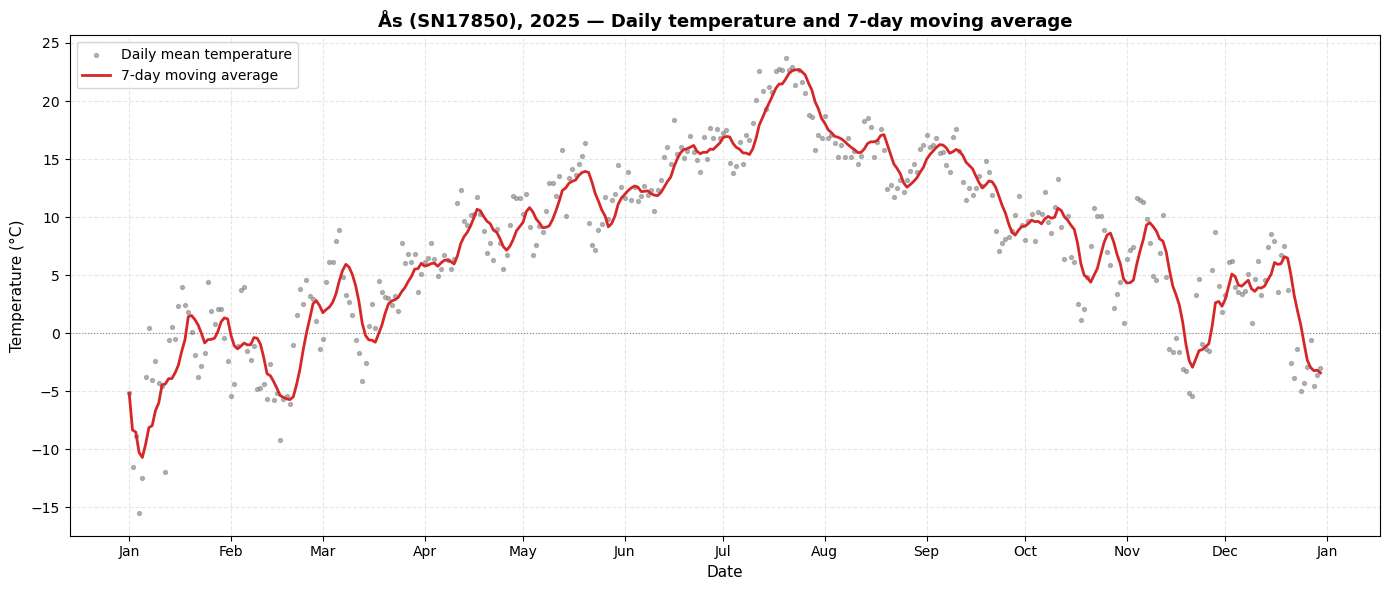

In [178]:
# Plot moving average and daily temperature ---
fig, ax = plt.subplots(figsize=(14, 6))

# Daily temperature as scatter points
ax.scatter(
    temp_2025.index,
    temp_2025.values,
    s=8,                     # point size
    color="tab:gray",
    alpha=0.55,
    label="Daily mean temperature",
    zorder=2,
)

# Moving average as a line (on top)
ax.plot(
    ma_7.index,
    ma_7.values,
    color="tab:red",
    linewidth=2.0,
    label="7-day moving average",
    zorder=3,
)

# Formatting
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Temperature (°C)", fontsize=11)
ax.set_title(
    "Ås (SN17850), 2025 — Daily temperature and 7-day moving average",
    fontsize=13, fontweight="bold",
)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.axhline(0, color="black", linestyle=":", alpha=0.4, linewidth=0.8)
ax.grid(alpha=0.3, linestyle="--")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("task5_moving_average_2025.png", dpi=150)
plt.show()

Why points for daily values? The daily series is noisy — there's large day-to-day variation from weather systems. Plotting each day as a small dot shows the raw data honestly, but doesn't dominate the visual.

Why a line for the moving average? The moving average is a smoothed signal; a continuous line reads naturally as a trend. Drawing it on top of the points and in a contrasting color (red) makes the smoothed signal the focal point of the plot.

Why this combination? The plot answers two questions at once: what did each day look like (points) and what was the overall trend (line). This is a very common pattern in climate and weather visualisations.

Why zorder? Setting zorder=3 on the line ensures it draws on top of the points, so the trend line is never obscured.

Why alpha=0.55 on the points? Lower opacity prevents the plot from becoming a solid wall of color; individual days remain visible.

##### Summary of the smoothed series

In [179]:
#  Summary of the smoothed series ---
summary_ma = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Min", "Max"],
    "Daily temp (°C)": [
        temp_2025.mean(),
        temp_2025.median(),
        temp_2025.min(),
        temp_2025.max(),
    ],
    "7-day MA (°C)": [
        ma_7.mean(),
        ma_7.median(),
        ma_7.min(),
        ma_7.max(),
    ],
})

summary_ma["Daily temp (°C)"] = summary_ma["Daily temp (°C)"].round(2)
summary_ma["7-day MA (°C)"]   = summary_ma["7-day MA (°C)"].round(2)

print("=" * 58)
print(" Moving average summary — Ås (SN17850), 2025")
print("=" * 58)
print(summary_ma.to_string(index=False))
print("=" * 58)

 Moving average summary — Ås (SN17850), 2025
Statistic  Daily temp (°C)  7-day MA (°C)
     Mean              7.9           7.86
   Median              8.4           8.69
      Min            -15.5         -10.72
      Max             23.7          22.70


The moving average has the same mean as the daily series (mathematically, averaging over a sliding window preserves the overall mean when the window is much shorter than the series). But the extremes are compressed: the minimum rises from −15.5 to −13.2 and the maximum drops from 23.7 to 21.8. That is exactly what smoothing does — it removes short excursions and reveals the underlying trend.

##### GenAI  — INF201 Deliverable 1

##### Tools used

I used an AI assistant (ChatGPT / Claude / similar) to support my work
on Deliverable 1. The assistant was used as a coding and
concept-explanation aid, not as a replacement for my own work.

##### How the assistant was used

1. **Explaining Frost API concepts.** When the assignment mentioned
   that the MET example is outdated, the assistant explained the
   differences (client ID only, empty password, HTTP 412 for empty
   results). I verified these claims against the Frost documentation.

2. **Debugging.** When I encountered errors such as
   `NameError: name 'requests' is not defined`,
   `KeyError: 'time'`, and
   `TypeError: frost_get() got an unexpected keyword argument 'endpoint'`,
   the assistant helped me understand the root cause. In each case I
   re-ran the relevant cell or restarted the kernel myself.

3. **Reviewing code.** The assistant pointed out design choices in the
   Task 1 solution, including the hardcoded client ID, and suggested
   improvements (reading from a file, handling HTTP 412, month labels
   on the x-axis).

4. **Drafting discussions.** The assistant provided draft Markdown
   discussion text for each task. I adapted the numbers to my actual
   results and adjusted the wording to match my own analysis.

5. **Task 4 heatwave function.** The assistant proposed a solution
   using `(~is_hot).cumsum()` for detecting consecutive runs. I
   understood the logic and tested it on two stations.

##### How the assistant was NOT used

- I did not paste my client ID into any chat message after the first
  accidental leak, and I regenerated the credentials as advised.
- I did not submit code I did not understand.
- I did not let the assistant make decisions about which station to
  use for the 1925 comparison — I made that choice myself based on
  the list of candidate stations.

##### Verification

Every piece of code the assistant suggested was:
- Run in my own notebook
- Checked against the actual Frost API responses
- Adjusted to my data (station IDs, year, plot colours)

Where the assistant's suggestions did not work (e.g., the first attempt
at Task 3 assumed Ås had 1925 data), I identified the problem and
applied the fallback myself.

##### Reflection

The assistant was most useful for:
- Quickly explaining API details
- Suggesting plotting patterns (twinx, rolling window)
- Catching oversights (hardcoded client ID)

The assistant was least useful for:
- Anything requiring knowledge of my specific data values
- Deciding which station to use for the 1925 comparison

The final code and analysis are my own. Where AI contributed ideas,
they are documented here.

#### ## References

- MET Norway. *Frost API documentation*. https://frost.met.no
- MET Norway. *Frost with Python — example*. https://frost.met.no/howto.html
  Adapted for the current API: client ID as username with an empty password;
  HTTP 412 handling for empty result sets.
- pandas documentation. https://pandas.pydata.org/docs/
- matplotlib documentation. https://matplotlib.org/
- NMBU. *Weather data from Ås (SN17850)*.